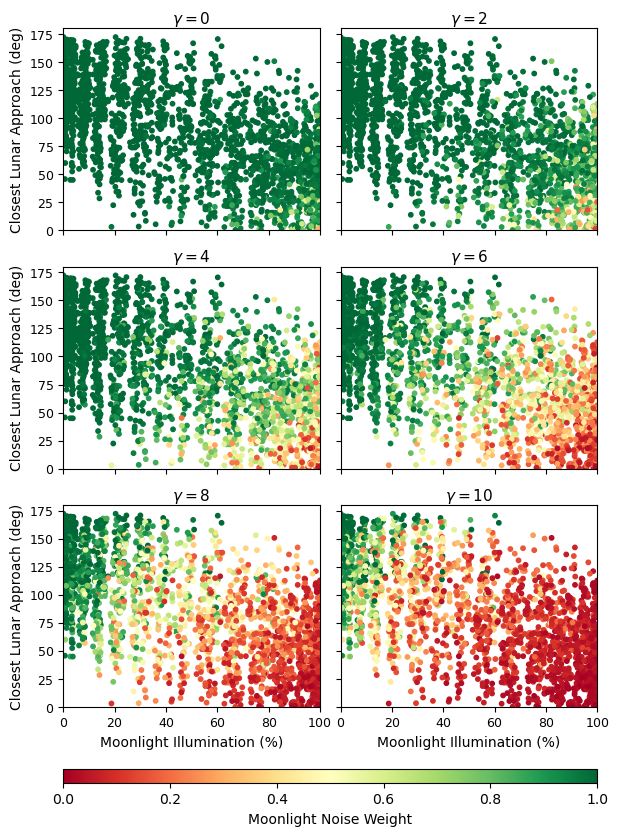

In [7]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Gamma values to compare
gammas = [0, 2, 4, 6, 8, 10]

base_dir = Path(r"C:\Users\WBS\Documents\PREFACE_benchmarks\gamma_benchmark")

fig, axes = plt.subplots(
    3,
    2,
    figsize=(6, 10),
    sharex=True,
    sharey=True,
)

axes = axes.ravel()

for i, gamma in enumerate(gammas):

    csv_path = (
        base_dir
        / f"gamma{gamma}"
        / "phase_2"
        / "full_ranked_event_list"
        / "Full_Event_List_for_TNT ULTRASPEC_r-band_for_Half_Well_Rank-modes_Y-SkyNoise_N-Defocus_97.0%_cut_from_Jan-01-2027_to_Feb-28-2027.csv"
    )

    events = pd.read_csv(csv_path)

    sc = axes[i].scatter(
        events["Lunar_Illumination"],
        events["Closest_Lunar_Approach"],
        c=events["Moon_Noise_Metric"],
        cmap="RdYlGn",
        vmin=0,
        vmax=1,
        s=10,
    )

    axes[i].set_title(rf"$\gamma={gamma}$", fontsize=11, pad=2)
    axes[i].set_xlim(0, 100)
    axes[i].set_ylim(0, 180)
    axes[i].tick_params(labelsize=9)

# Left column y-labels
for ax in axes[::2]:
    ax.set_ylabel("Closest Lunar Approach (deg)")

# Bottom row x-labels
for ax in axes[-2:]:
    ax.set_xlabel("Moonlight Illumination (%)")

fig.subplots_adjust(
    left=0.09,
    right=0.98,
    bottom=0.16,
    top=0.94,
    wspace=0.08,
    hspace=0.18,
)

# Horizontal colorbar at bottom
cbar = fig.colorbar(
    sc,
    ax=axes,
    orientation="horizontal",
    fraction=0.05,
    pad=0.08,
    aspect=40,
)

cbar.set_label("Moonlight Noise Weight")

plt.show()